#  Fine-Tuning Qwen2.5-VL (7B) 
#### Vision-Language Understanding

> **Objective:** Adapt Qwen2.5-VL (7B parameter vision-language model) for improved visual understanding and reasoning  
> **Method:** Supervised Fine-Tuning (SFT) with LoRA using Unsloth for multimodal tasks  
> **Dataset:** Custom vision-language dataset (images + text Q&A pairs)  
> **Hardware:** Google Colab T4 GPU (15GB VRAM)

---

## What is Qwen2.5-VL?

**Qwen2.5-VL** (released October 2024) is Alibaba's latest open-source **vision-language model**:
- **Multimodal architecture:** Processes both images and text inputs simultaneously
- **7B parameters:** Large enough for strong visual reasoning, small enough for consumer GPUs
- **Capabilities:** Visual question answering (VQA), image captioning, document understanding, chart analysis

**Key innovation over text-only LLMs:**
- Integrated **vision encoder** (pre-trained on billions of image-text pairs)
- Cross-modal attention layers that fuse visual and linguistic information
- Can answer questions about uploaded images: "What color is the car?" → model sees image + question → generates text answer

---

---

## Architecture: How Vision-Language Models Work

```
Image Input              Text Input
     ↓                       ↓
Vision Encoder          Text Embeddings
(frozen CNN/ViT)        (trainable)
     ↓                       ↓
Visual Features ──┐    ┌─ Text Features
                   ↓    ↓
            Cross-Modal Attention
            (multimodal fusion)
                   ↓
            Language Model
            (7B params)
                   ↓
            Text Output
```

**Key components:**
- **Vision Encoder:** Pre-trained CNN or Vision Transformer (ViT) that extracts image features → typically **frozen** during fine-tuning
- **Projection Layer:** Maps visual features to language model's embedding space
- **Language Model:** 7B parameter transformer that generates text (attends to both image and text)

---

## Fine-Tuning Strategy: LoRA on Language Model Only

### Why Not Fine-Tune the Vision Encoder?

**Option 1: Fine-tune everything (vision + language)**
- Requires 20GB+ VRAM (entire model trainable)
- Risk: Catastrophic forgetting of visual representations
- **Not feasible on T4**

**Option 2: Fine-tune language model only (our approach)**
- Vision encoder stays frozen (keeps strong pre-trained visual features)
- Add LoRA adapters to language model layers
- Requires 8GB VRAM with 4-bit quantization
- **Works on T4, preserves visual capabilities**

---

## Technical Stack

| Component | Technology | Purpose |
|-----------|-----------|---------|
| **Model** | Qwen2.5-VL (7B) | Vision-language base model |
| **Vision Encoder** | ViT (frozen) | Extract image features |
| **Quantization** | 4-bit (QLoRA) | Reduce memory 28GB → 8GB |
| **Adapter** | LoRA (r=16, α=16) | Trainable layers on language model |
| **Training** | Unsloth + SFTTrainer | 2× faster multimodal fine-tuning |
| **Monitoring** | Weights & Biases | Track loss, GPU usage |

---


# **Setting Up GPU and APIs Access**


 **Enable GPU Support in Google Colab**
To speed up training, you can run your code on a GPU.

> Go to the top menu:

Runtime > Change runtime type > Hardware accelerator > GPU

> Then click Save.

Colab offers free access to NVIDIA GPUs like **Tesla T4**, but usage limits may apply depending on availability.

🔑 **Setting Up Hugging Face API Access**
1. If you haven't already, create a free account on [Hugging Face](https://huggingface.co/settings/tokens).

2. Navigate to Access Tokens.

3. Click "New Token", and give it a name.

4. Choose "read" or "read/write" permissions as required.

5. Copy your token. We'll use it in Colab shortly.

🔑 **Setting Up Weights & Biases (W&B) API Key**
1. Sign up at Weights & Biases.

2. Go to your [W&B Settings](https://wandb.ai/settings).

3. Scroll down to find your API Key under the "API Keys" section.

4. Copy the key for use in your notebook.

**We are Setting up HF API Access**
- To load any private model/dataset (Most of the model/datset are public. This colab also uses public one)
- Push the model to HF

**We are Setting up W&B**
- To track, visualize, compare the loss, accuracy, learning rate, etc.

In [ ]:
# 🛠️ Environment Setup: Hugging Face & W&B Login Using Colab Secrets (new API)

from google.colab import userdata
from huggingface_hub import login
import wandb

# Retrieve tokens using Colab's Secrets API
hft = userdata.get("hft-qwen")
wandb_token = userdata.get("wandb-qwen")


# Login to Hugging Face
login(token=hft)

# Login to Weights & Biases
wandb.login(key=wandb_token)

# Initialize a W&B run
run = wandb.init(
    project='Fine-tune-Qwen2.5-VL',
    job_type="training",
    anonymous="allow"
)

# W&B is a tool for experiment tracking, model monitoring, and visualization in Deep learning projects.

# Think of it as your project’s AI lab assistant — it watches your training, records everything, and gives you pretty dashboards so you can analyze what’s happening under the hood.



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 22f1000589 (22f1000589-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


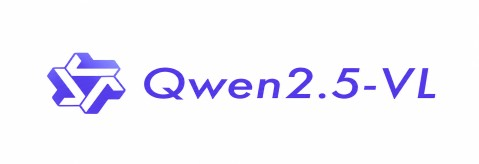

# Workflow for Fine-tuning Qwen2.5 VL(7B)-Vision:

---

1. **Install Dependencies and Import Modules**

   * Install `unsloth`
   * Import necessary libraries for model, dataset, and training.

2. **Prepare the Model and Dataset**

   **a. Model Preparation:**

   * Load base model (`unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit`) with 4-bit quantization (QLoRA).
   * Add **LoRA adapters** to attention, feedforward, vision, language layers .

   **b. Dataset Preparation:**

   * Load dataset (e.g., unsloth/LaTeX_OCR).
   * Reformatting our image-text dataset(unsloth/LaTeX_OCR) into the structure expected by multimodal chat models like Qwen2.5-VL.



3. **Train the Model with Supervised Fine-Tuning (SFT)**

   * Use `SFTTrainer` to fine-tune only the **LoRA** layers using the formatted dataset.

4. **Save & Reload the Fine-Tuned Model for Inference**

   * Save the LoRA adapters
   * Reload for inference.
   * Inference - Define user prompts, Reformatt the dataset, tokenize input, and generate response.
   - Save the Finetuned Model Locally and Online(Push to HF)


## 1. Install Dependencies — Unsloth with Vision Support

### Why Unsloth for Vision-Language Models?

**Unsloth** extends its optimizations to multimodal models:
- **2× faster training** on vision-language tasks
- **Optimized vision-text fusion** — efficient cross-modal attention
- **Memory-efficient image encoding** — batched image processing
- **Native support for Qwen2.5-VL** architecture

### Key Dependencies

| Library | Purpose |
|---------|---------|
| `unsloth` | Fast multimodal fine-tuning framework |
| `transformers` | Hugging Face model hub integration |
| `datasets` | Load image-text datasets |
| `pillow` | Image loading and preprocessing |
| `torch` | PyTorch for tensor operations |
| `peft` | LoRA implementation |
| `trl` | SFTTrainer for supervised fine-tuning |

**Installation note:** Unsloth automatically detects vision model architecture and applies appropriate optimizations.

---

In [ ]:
%%capture
import os      #Capture suppresses the output of the cell (like download logs).  Import Python's os module to interact with environment variables.
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth       # Check if we are not in Google Colab. If not Colab, simply install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl triton cut_cross_entropy unsloth_zoo      #bitsandbytes, accelerate, xformers, etc. for model optimization.
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer         # for tokenizer and dataset support.
    !pip install --no-deps unsloth

# **2. Prepare the Model and Dataset**

# 2.a Model Preparation

Load base model (unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit) with 4-bit quantization (QLoRA).

In [ ]:
import torch
from unsloth import FastVisionModel      #A high-performance vision-language model class from Unsloth.

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth"   #using Unsloth’s custom checkpointing we r going to activates memory-efficient training mode
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.6.5: Fast Qwen2 patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.97G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.02k [00:00<?, ?B/s]

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.


Display picture of all the examples.
This setup is common in image captioning, visual question answering etc

Below you can see
-We convert a image to a series of image patches or tokens which we are going to pass to the Vision/image Encoder(which is CLIP or ViT, and weights are frozen here since snowflake icon)
- The output of the vision/image encoder is passed through an MLP(feed forward NN), which likely transforms the visual features into a format compatible with the language model.
- Language model takes text input tokens(yellow block) and the encoded vision tokens(blue block)
**And thus generates text using both visual and textual context.**

This diagram is for visual question answering,
like
Image- A photo showing a person made a mustache out of banana
Question- What is mustache made of?
VL process both image and text.
here we can see Image(blue block) and the question token(yellow block)

So, Where to Add LoRA adpaters?
Add **LoRA adapters** to attention,feedforward, vision, language layers .

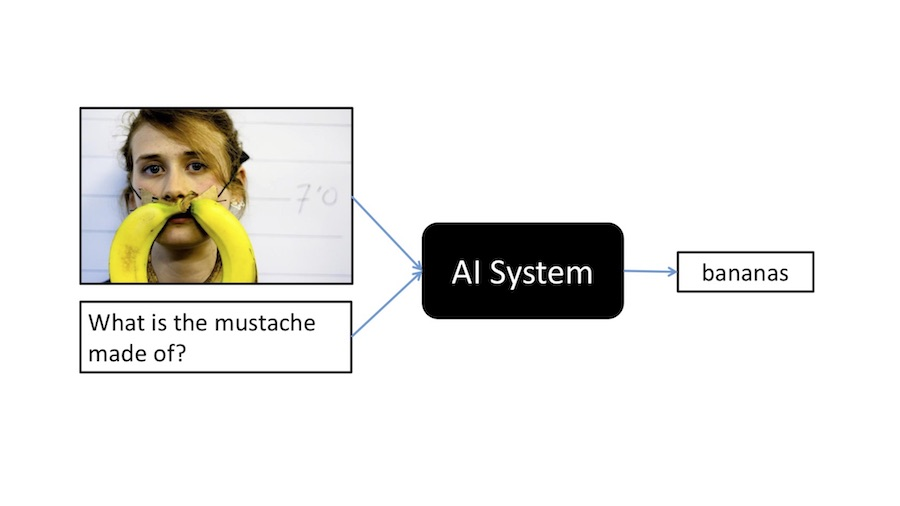

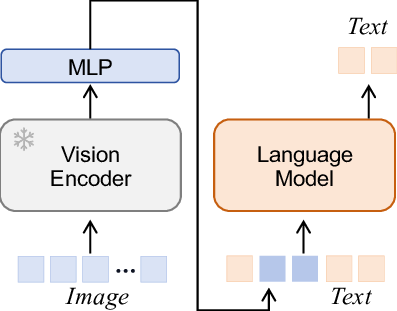

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Scaling factor for the LoRA matrices. Recommended alpha == r at least
    lora_dropout = 0,   #Dropout rate in LoRA (helps prevent overfitting).
    bias = "none",        #Whether to apply LoRA to biases. "none" means only weight matrices are adapted.
    random_state = 3407,   #Random seed to ensure reproducibility.
)

So in this snippet what happend
- we Freezed most weights.
- Injected LoRA adapters in selected submodules.
- Allowed weight updates only to those small adapter layers.


# 2.b Dataset Preparation

### Common Dataset Structures

**1. Visual Question Answering (VQA):**
```
Image: photo of traffic scene
Q: "Is the traffic light red or green?"
A: "The traffic light is red."
```

**2. Image Captioning:**
```
Image: sunset over mountains
Q: "Describe this image."
A: "A breathtaking sunset over snow-capped mountains with orange and pink sky."
```

**3. Document Understanding:**
```
Image: scanned invoice
Q: "What is the total amount?"
A: "The total amount is $1,247.50."
```

Load dataset (e.g., unsloth/LaTeX_OCR). Optical Character Recognition

In [ ]:
from datasets import load_dataset                           #Imports the load_dataset function from Hugging Face’s datasets library.
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")         #loads the "train" split of the dataset

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

In [ ]:
dataset[2]            #2nd row before reformatting

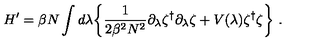

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

Reformatting our image-text dataset(unsloth/LaTeX_OCR) into the structure expected by multimodal chat models like Qwen2.5-VL.



This allows us to fine-tune the model as if it's learning from a **conversation** between a user and an assistant(and this learning is a Supervised learning), where:


*   The user shows an image and gives an instruction.
*   The assistant replies with the LaTeX representation.



In [ ]:
instruction = "Write the LaTeX representation for this image."   # A fixed instruction prompt to guide the model.

def convert_to_conversation(sample):
    conversation = [               #this conversation is a list of dict. 1st dict is of user , 2nd dict is of assistant
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},      #indicates that this piece of content is a textual message,  # the actual text content
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

In [ ]:
convert_to_conversation(dataset[2])

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [ ]:
converted_dataset[1]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=120x50>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'D _ { \\mu } ^ { \\alpha \\beta } \\bar { A } _ { \\mu } ^ { \\alpha \\beta } = 0 ,'}]}]}

Let's first see before we do any finetuning what the model outputs for the third example!



In [1]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]                                         #Input image
instruction = "Write the LaTeX representation for this image."      #Input instruction

messages = [
    {"role": "user", "content": [                           # reformatted the input(image and instruction) as expected by Qwen2.5Vl model
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
# Applies the chat template expected by the model’s tokenizer.
# Converts the messages list into a properly formatted string input
# add_generation_prompt=True: tells the model to get ready to generate a response (i.e., append special tokens like <|im_start|>assistant\n).


inputs = tokenizer(
    image,            #Tokenizes the image + input_text together for inference.
    input_text,
    add_special_tokens = False,   #<pad>,<sep>- separator toke
    return_tensors = "pt",      # Converts it into PyTorch tensors.
).to("cuda")                     # Moves everything to GPU (cuda) for fast generation.

from transformers import TextStreamer              #lets the output stream to console token by token (real-time generation).
text_streamer = TextStreamer(tokenizer, skip_prompt = True)        #skip_prompt=True: only display the model’s response, not the input.
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,   #limit on response length, # cache - enables faster decoding with past key-values.
                   use_cache = True, temperature = 1.5, min_p = 0.1)         # adds randomness (diversity) to the output.
# part of top-p sampling, ensures tokens have minimum cumulative probability mass.

NameError: name 'FastVisionModel' is not defined

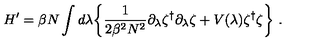

In [ ]:
image

# **3. Train the Model with Supervised Fine-Tuning (SFT)**

In [ ]:
from unsloth import is_bf16_supported               #Checks if your GPU supports bfloat16 (for mixed-precision training).
from unsloth.trainer import UnslothVisionDataCollator    # Special data collator that formats image + text batches properly, i.e its going to - Pairs the image and text fields correctly, Pads inputs, Handles visual token masks.
from trl import SFTTrainer, SFTConfig         #TRL’s training loop + configuration for supervised fine-tuning.

In [ ]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,          #The finetune-ready Qwen2.5-VL model and tokenizer.
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,      # The dataset which we have previously converted to chat-style messages that Qwen2.5VL supports
    args = SFTConfig(
        per_device_train_batch_size = 2,     #Number of training examples processed per GPU in each forward/backward pass.
        gradient_accumulation_steps = 4,        #Number of steps to accumulate gradients before doing a backward update, Accumulates gradients over 4 steps before doing a backward pass.,  Simulates larger batch size (2 × 4 = 8 effective batch size).
        warmup_steps = 5,          # Number of steps to gradually increase learning rate from zero to target.
        max_steps = 30,            # Only train for 30 steps — useful for quick prototyping.
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,   # Controls how much the model weights are updated at each step. High LR like 2e-4 is typical for LoRA fine-tuning.
        logging_steps = 1,         #Log training metrics every 1 step. , Good for small-step debugging.
        optim = "adamw_8bit",      #Uses AdamW optimizer in 8-bit precision (via bitsandbytes). this optimizer Reduces memory usage significantly.
        weight_decay = 0.01,           # uses Regularization to penalize large weights (helps generalization of the model).
        lr_scheduler_type = "linear",    #How learning rate is adjusted during training. # other values like constant , cosine etc
        seed = 3407,                        #Fixes randomness for reproducibility.
        output_dir = "outputs",        #Where model checkpoints and logs will be saved.
        report_to = "none",          # Disables logging to tools like wandb, tensorboard

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,        #Prevents auto-removal of columns not used by the model, otherwise vision tokens are discarded.
        dataset_text_field = "",              #when we where finetuning the text language like llama we set it to "text", because that was the reformatted input field
        dataset_kwargs = {"skip_prepare_dataset": True},     # Avoids re-processing if you've already structured your dataset
        dataset_num_proc = 4,           # Number of CPU processes to use for data loading and pre-processing.
        max_seq_length = 2048,           # Max number of tokens per input example.
    ),
)

average_tokens_across_devices is set to True but it is invalid when world size is1. Turn it to False automatically.


Unsloth: Model does not have a default image size - using 512


### What the Model is Learning

**Early training (steps 1-20):**
- Basic visual grounding: "This is an image of X"
- Spatial awareness: "The object is on the left"
- Color/shape recognition: "A red circle"

**Mid training (steps 20-40):**
- Visual reasoning: "The traffic light is red, so cars should stop"
- Contextual understanding: "This is a medical scan showing..."
- Multi-object tracking: "There are 3 people and 2 dogs"

**Late training (steps 40+):**
- Domain-specific patterns: "This X-ray shows signs of pneumonia"
- Complex reasoning: "Based on the chart, Q3 revenue exceeded projections"
- Style alignment: Matching your desired response format

### Monitoring with W&B

**Vision-specific metrics to watch:**
- **Training loss:** Should decrease steadily
- **GPU memory:** Should stay under 14GB (T4 limit)
- **Images/second:** ~0.5-1.0 images/sec on T4 (slower than text-only)
- **Visual token count:** Should be consistent (~256 per image)

In [ ]:
trainer_stats = trainer.train()         #starts the training loop using the Hugging Face SFTTrainer. And what we are passing? A supervised reformatted conversation

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,521,536/7,000,000,000 (0.74% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
1,2.787500
2,3.325900
3,3.432400
4,2.313600
5,2.054400
6,2.038900
7,1.522800
8,1.005100
9,0.716700
10,0.744900


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


# **4. Save & Reload the Fine-Tuned Model for Inference**

Save the LoRA adapters

**[NOTE]** This ONLY saves the **LoRA adapters**, and not the full model, After inferencing we are going to see how to save the full model and then push it to HF

In [ ]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")

Reload it

In [ ]:
if True:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!


Inference

## Test Fine-Tuned Model — Visual Question Answering

### Inference Pipeline

```python
# 1. Load image
image = Image.open("test_image.jpg")

# 2. Format prompt with <image> token
prompt = "<image>What do you see in this image?"

# 3. Process inputs (image + text)
inputs = processor(images=image, text=prompt, return_tensors="pt")

# 4. Generate response
output = model.generate(**inputs, max_new_tokens=256)

# 5. Decode tokens to text
response = processor.decode(output[0])
```

### Expected Improvements

| Aspect | Base Qwen2.5-VL | Fine-Tuned |
|--------|-----------------|------------|
| **Domain vocabulary** | Generic (car, person, building) | Specialized (radiograph, lesion, diagnosis) |
| **Visual detail** | Surface-level ("A medical image") | Specific ("Chest X-ray showing right lower lobe opacity") |
| **Reasoning depth** | Descriptive | Analytical ("Consistent with pneumonia; recommend follow-up") |
| **Response format** | Varies | Consistent with training examples (e.g., structured reports) |

### Testing Best Practices

**1. Test on held-out images** (not in training set)
- Ensures model generalizes, not memorizes

**2. Compare base vs fine-tuned side-by-side**
```python
base_response = base_model.generate(inputs)
finetuned_response = finetuned_model.generate(inputs)
# Which is more accurate/helpful/domain-appropriate?
```

**3. Test edge cases**
- Low-quality images (blurry, dark)
- Unusual angles or compositions
- Multiple objects/complex scenes

**4. Check for hallucinations**
- Does model make up details not visible in image?
- Does it refuse when appropriate ("I cannot determine from this image")?

### Inference Optimization

```python
FastLanguageModel.for_inference(model)
```

**Unsloth inference optimizations:**
- KV-cache reuse across tokens
- Optimized cross-modal attention (faster vision-text fusion)
- **Result:** 2× faster generation vs standard Hugging Face

### Generation Parameters

```python
model.generate(
    max_new_tokens=256,        # Response length
    temperature=0.7,           # Lower = more deterministic
    top_p=0.9,                 # Nucleus sampling
    repetition_penalty=1.1,    # Reduce repetition
    do_sample=True             # Enable sampling
)
```

**For vision tasks:**
- Lower temperature (0.5-0.7) for factual descriptions
- Higher temperature (0.8-1.0) for creative captioning

---

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

H ^ { \prime } = \beta N \int d \lambda \left\{ - \frac 1 { 2 \beta ^ { 2 } \pi N ^ { 2 } } \partial _ { \lambda } \zeta ^ { i } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { i } * \zeta \right\} .<|im_end|>


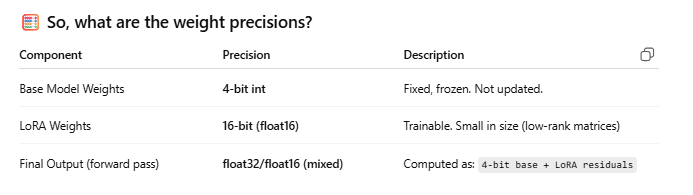

W_eff = W_4bit + LoRA_update(W_4bit)

# Export to HF

In [ ]:
# Save to 16bit

# Locally
model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "PUT_HERE")

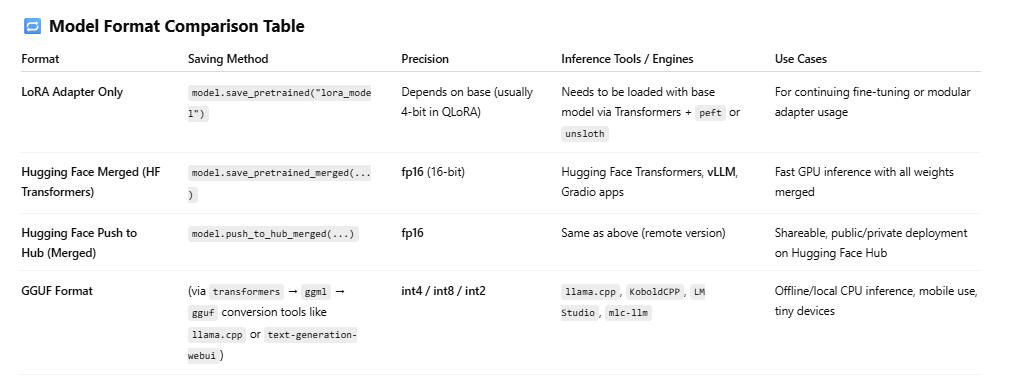

**GGUF** (short for "GGML Unified Format") is a new file format used to store quantized large language models for use with the llama.cpp

**llama.cpp** is a **CPU-based** inference engine for running LLaMA and similar transformer models locally




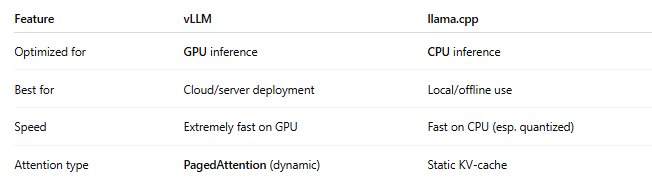